In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# Run from LargeExample_ERS_Change folder, or set path explicitly
base_path = Path(".").resolve()

# ── Shared style settings ──
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#cccccc",
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    "font.family": "serif",
    "font.size": 12,
})

# Algorithm colors and hatches (design inspiration: distinct per algorithm)
GA_COLOR, GA_HATCH = "#228B22", "."   # green, dots
AC_COLOR, AC_HATCH = "#E8860C", "\\"  # orange, backslash
CW_COLOR, CW_HATCH = "#B22222", "-"   # red, horizontal


def plot_bar_from_csv(csv_name: str, y_label: str):
    """Grouped bar chart for GA, AC, CW."""
    df = pd.read_csv(base_path / csv_name)
    configs = df["ers_config"].astype(str).values
    x_labels = [c.replace("_", ".") for c in configs]
    n = len(configs)
    group_spacing = 4.0  # space between bar groups
    x = np.arange(n) * group_spacing
    width = 1.0  # wide enough for clear data labels

    fig, ax = plt.subplots(figsize=(12, 5))

    algos = [("Genetic algorithm", df["GA"].values, GA_COLOR, GA_HATCH),
             ("Ant Colony", df["AC"].values, AC_COLOR, AC_HATCH),
             ("Clarke and Wright", df["CW"].values, CW_COLOR, CW_HATCH)]
    offsets = [-width, 0, width]

    for (label, vals, color, hatch), off in zip(algos, offsets):
        vals = np.asarray(vals, dtype=float)
        bars = ax.bar(
            x + off, vals, width,
            label=label, color=color,
            edgecolor="black", linewidth=0.8,
            hatch=hatch,
        )
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h) and h > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2, h + 0.5,
                    f"{h:.2f}", ha="center", va="bottom",
                    fontsize=10, fontweight="bold",
                )

    ax.set_xlabel("ERS Ratio", fontsize=13, fontweight="bold")
    ax.set_ylabel(y_label, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    ax.set_axisbelow(True)
    all_vals = np.concatenate([df["GA"].values, df["AC"].values, df["CW"].values])
    valid = np.asarray(all_vals, dtype=float)
    valid = valid[~np.isnan(valid)]
    if len(valid):
        ymin, ymax = valid.min(), valid.max()
        margin = (ymax - ymin) * 0.15 if ymax > ymin else 1
        ax.set_ylim(bottom=max(0, ymin - margin), top=ymax + margin)
    plt.tight_layout()
    plt.show()


def plot_runtime_line(csv_name: str = "runtime.csv"):
    """Line chart for runtime (GA, AC, CW)."""
    df = pd.read_csv(base_path / csv_name)
    for col in ["GA", "AC", "CW"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").interpolate(method="linear")
    configs = df["ers_config"].values
    x_labels = [str(c).replace("_", ".") for c in configs]
    ga_vals = df["GA"].values.astype(float)
    ac_vals = df["AC"].values.astype(float)
    cw_vals = df["CW"].values.astype(float)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(len(configs)), ga_vals, color=GA_COLOR, marker="o", markersize=8, linestyle="-", linewidth=2, label="Genetic algorithm")
    ax.plot(range(len(configs)), ac_vals, color=AC_COLOR, marker="v", markersize=8, linestyle="--", linewidth=2, label="Ant Colony")
    ax.plot(range(len(configs)), cw_vals, color=CW_COLOR, marker="s", markersize=8, linestyle="-.", linewidth=2, label="Clarke and Wright")

    ax.set_xlabel("ERS Ratio", fontsize=13, fontweight="bold")
    ax.set_ylabel("Execution Time (sec)", fontsize=13, fontweight="bold")
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

## Runtime

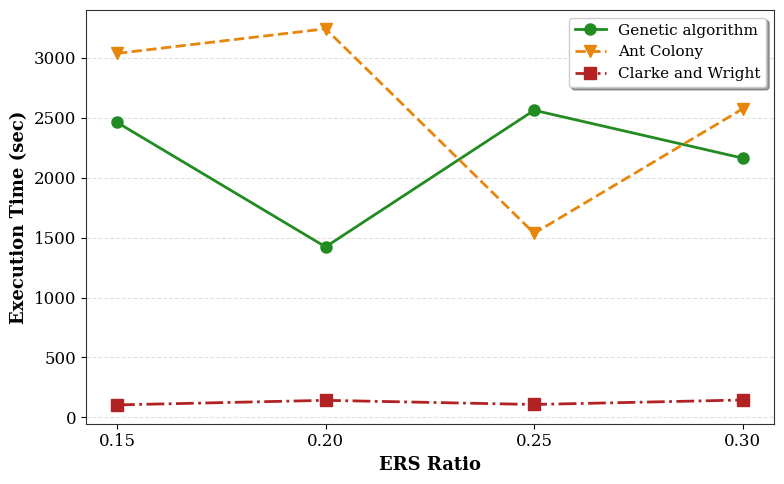

In [14]:
plot_runtime_line("runtime.csv")

## Distance

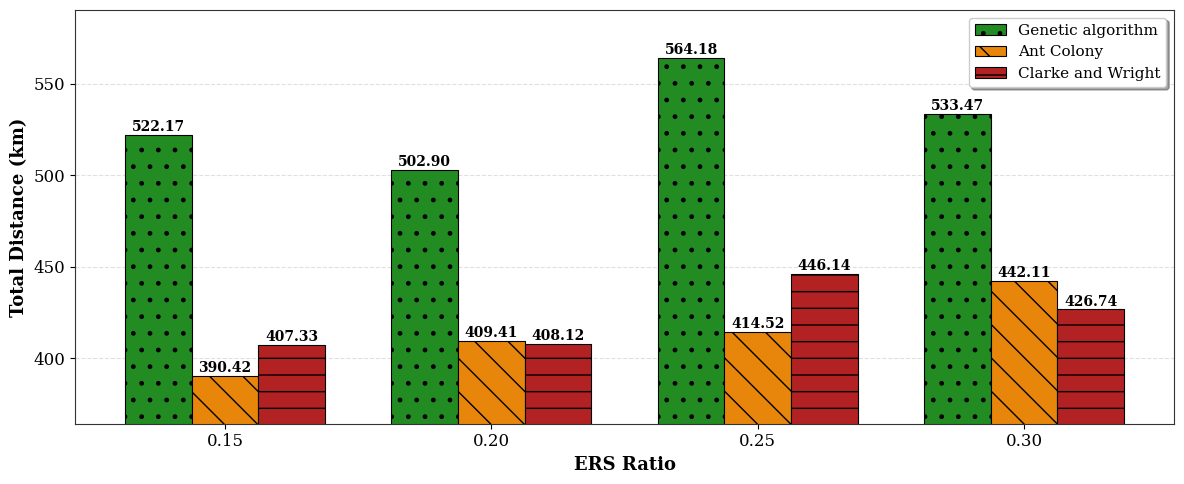

In [15]:
plot_bar_from_csv("distance.csv", "Total Distance (km)")

## Travel Time

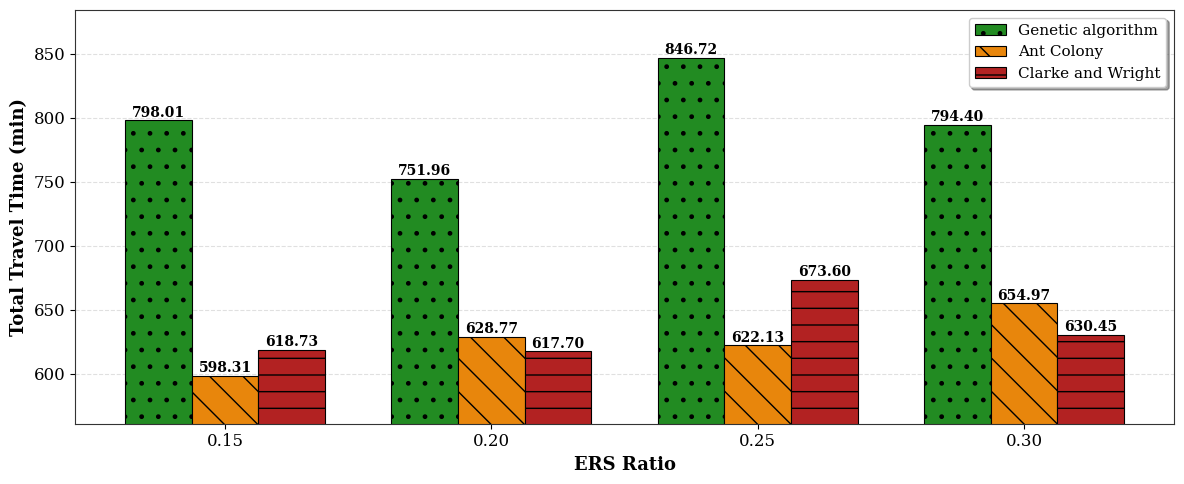

In [16]:
plot_bar_from_csv("travelTime.csv", "Total Travel Time (min)")

## Energy Consumption

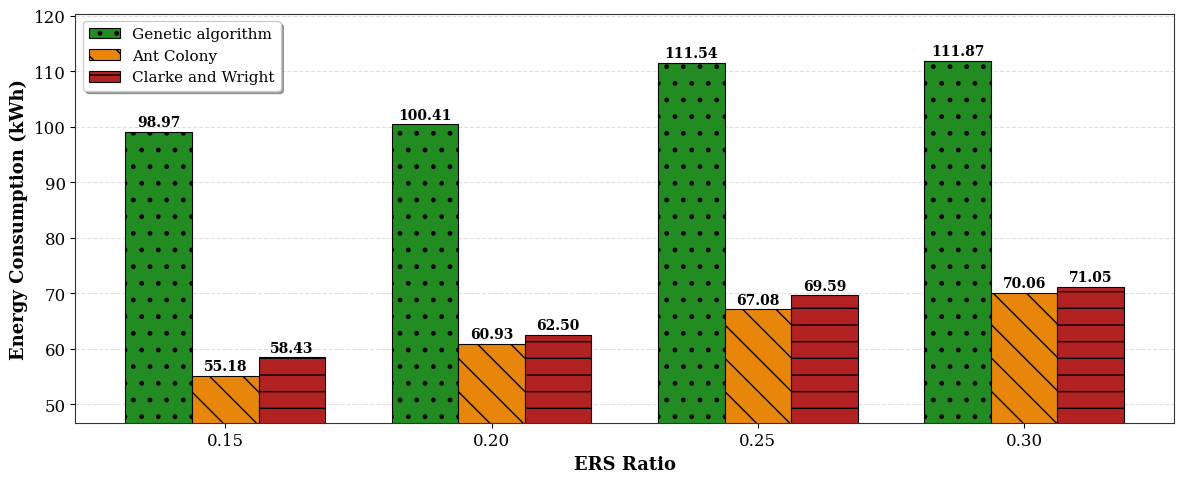

In [17]:
plot_bar_from_csv("energy_consumption.csv", "Energy Consumption (kWh)")

## Energy Charge (CS vs ERS)

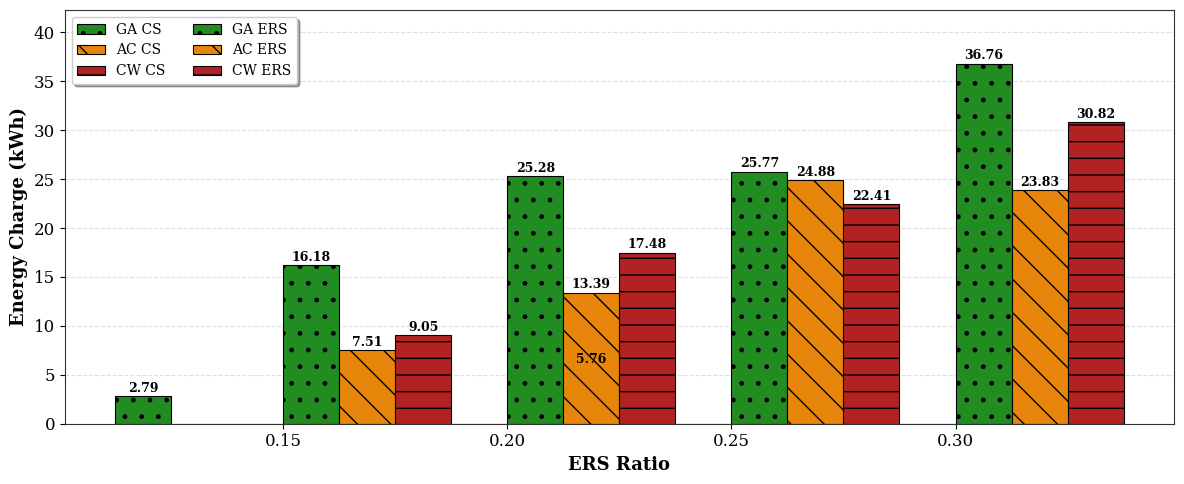

In [18]:
df_cs = pd.read_csv(base_path / "energy_charge_CS.csv")
df_ers = pd.read_csv(base_path / "energy_charge_ERS.csv")

configs = df_cs["ers_config"].astype(str).values
x_labels = [c.replace("_", ".") for c in configs]
n = len(configs)
group_spacing = 4.0  # space between bar groups
x = np.arange(n) * group_spacing
width = 1.0  # wide enough for clear data labels

vals = {
    "GA CS": df_cs["GA"].values,
    "AC CS": df_cs["AC"].values,
    "CW CS": df_cs["CW"].values,
    "GA ERS": df_ers["GA"].values,
    "AC ERS": df_ers["AC"].values,
    "CW ERS": df_ers["CW"].values,
}
colors = [GA_COLOR, AC_COLOR, CW_COLOR, GA_COLOR, AC_COLOR, CW_COLOR]
hatches = [GA_HATCH, AC_HATCH, CW_HATCH, GA_HATCH, AC_HATCH, CW_HATCH]
offsets = np.arange(6) * width - 2.5 * width

fig, ax = plt.subplots(figsize=(12, 5))

for (label, v), color, hatch, off in zip(vals.items(), colors, hatches, offsets):
    v = np.asarray(v, dtype=float)
    bars = ax.bar(
        x + off, v, width,
        label=label, color=color,
        edgecolor="black", linewidth=0.8, hatch=hatch,
    )
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h) and h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 0.15,
                f"{h:.2f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold",
            )

ax.set_xlabel("ERS Ratio", fontsize=13, fontweight="bold")
ax.set_ylabel("Energy Charge (kWh)", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=12)
ax.legend(fontsize=10, frameon=True, fancybox=True, shadow=True, ncol=2)
ax.set_axisbelow(True)

all_vals = np.concatenate([np.asarray(a, dtype=float) for a in vals.values()])
valid = all_vals[~np.isnan(all_vals)]
if len(valid):
    ymin, ymax = valid.min(), valid.max()
    margin = (ymax - ymin) * 0.15 if ymax > ymin else 0.5
    ax.set_ylim(bottom=max(0, ymin - margin), top=ymax + margin)

plt.tight_layout()
plt.show()